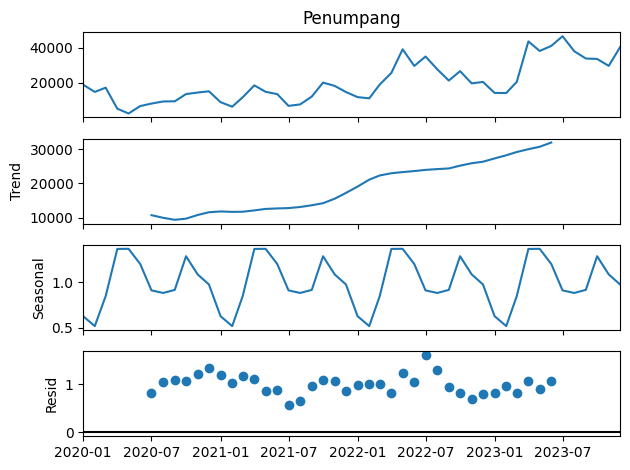

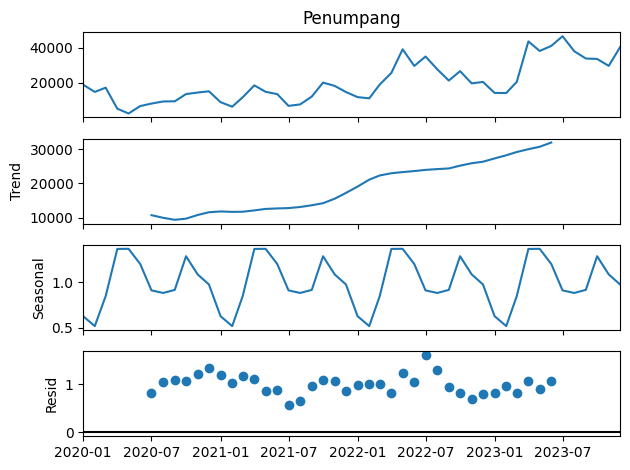

In [16]:

# Importing required libraries 
import numpy as np 
import pandas as pd 
import matplotlib as plt 
from statsmodels.tsa.seasonal import seasonal_decompose 
  
# Read the AirPassengers dataset 
sea_passanger = pd.read_csv('2020-2023_norm.csv',
                            index_col ='Tahun', 
                            parse_dates = True) 
  
# Print the first five rows of the dataset 
sea_passanger.head(5) 
  
# ETS Decomposition 
result = seasonal_decompose(sea_passanger['Penumpang'],  
                            model ='multiplicative') 
  
# ETS plot  
result.plot() 


In [20]:
# Import the library 
from pmdarima import auto_arima 

# Ignore harmless warnings 
import warnings 
warnings.filterwarnings("ignore") 

# Fit auto_arima function to AirPassengers dataset 
stepwise_fit = auto_arima(sea_passanger['Penumpang'], start_p = 1, start_q = 1, 
						max_p = 3, max_q = 3, m = 12, 
						start_P = 0, seasonal = True, 
						d = None, D = 1, trace = True, 
						error_action ='ignore', # we don't want to know if an order does not work 
						suppress_warnings = True, # we don't want convergence warnings 
						stepwise = True)		 # set to stepwise 

# To print the summary 
stepwise_fit.summary() 


Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=751.189, Time=0.36 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=757.353, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=748.734, Time=0.16 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=751.303, Time=0.25 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=775.135, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=752.839, Time=0.05 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=750.730, Time=0.54 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=750.541, Time=0.30 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=748.844, Time=0.18 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=752.495, Time=0.72 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=758.187, Time=0.10 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=750.233, Time=0.26 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=750.421, Time=0.23 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=752.120, Time=0.13 sec
 ARIMA(2,0,1)(1,1,0)[12] intercep

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                   48
Model:             SARIMAX(1, 0, 0)x(1, 1, 0, 12)   Log Likelihood                -370.367
Date:                            Mon, 08 Jul 2024   AIC                            748.734
Time:                                    10:37:49   BIC                            755.068
Sample:                                01-01-2020   HQIC                           750.945
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   4234.0743   2466.620      1.717      0.086    -600.412    9068.561
ar.L1          0.5739      0.199      2.890      0.004       0.185       0.963
ar.S.L12      -0.4505      0.140     -3.214      0.001      -0.725      -0.176
sigma2      4.719e+07      0.246   1.92e+08      0.000    4.72e+07    4.72e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.26   Jarque-Bera (JB):                 1.78
Prob(Q):                              0.61   Prob(JB):                         0.41
Heteroskedasticity (H):               1.18   Skew:                             0.52
Prob(H) (two-sided):                  0.78   Kurtosis:                         3.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 8.86e+23. Standard errors may be unstable.
"""

In [21]:
# Split data into train / test sets 
train = sea_passanger.iloc[:len(sea_passanger)-12] 
test = sea_passanger.iloc[len(sea_passanger)-12:] # set one year(12 months) for testing 

# Fit a SARIMAX(0, 1, 1)x(2, 1, 1, 12) on the training set 
from statsmodels.tsa.statespace.sarimax import SARIMAX 

model = SARIMAX(train['Penumpang'], 
				order = (0, 1, 1), 
				seasonal_order =(2, 1, 1, 12)) 

result = model.fit() 
result.summary() 


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                          Penumpang   No. Observations:                   36
Model:             SARIMAX(0, 1, 1)x(2, 1, 1, 12)   Log Likelihood                -235.487
Date:                            Mon, 08 Jul 2024   AIC                            480.974
Time:                                    10:39:21   BIC                            486.651
Sample:                                01-01-2020   HQIC                           482.402
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0602      0.256     -0.235      0.814      -0.563       0.442
ar.S.L12      -0.5139     89.966     -0.006      0.995    -176.845     175.817
ar.S.L24      -0.4501     32.706     -0.014      0.989     -64.552      63.652
ma.S.L12      -0.0107    112.915  -9.49e-05      1.000    -221.321     221.299
sigma2      4.829e+07      0.000   1.35e+11      0.000    4.83e+07    4.83e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 1.34
Prob(Q):                              0.84   Prob(JB):                         0.51
Heteroskedasticity (H):               2.10   Skew:                             0.59
Prob(H) (two-sided):                  0.32   Kurtosis:                         3.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.08e+27. Standard errors may be unstable.
"""

<Axes: xlabel='Tahun'>

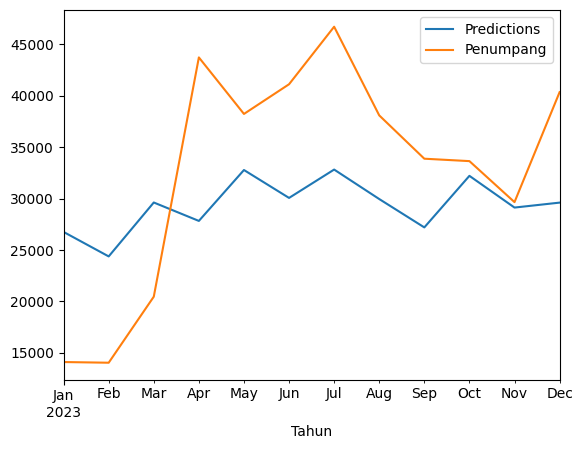

In [22]:
start = len(train) 
end = len(train) + len(test) - 1

# Predictions for one-year against the test set 
predictions = result.predict(start, end, 
							typ = 'levels').rename("Predictions") 

# plot predictions and actual values 
predictions.plot(legend = True) 
test['Penumpang'].plot(legend = True) 


In [25]:
# Load specific evaluation tools 
from sklearn.metrics import mean_squared_error 
from statsmodels.tools.eval_measures import rmse 

# Calculate root mean squared error 
rmse(test["Penumpang"], predictions) 



9906.80393293946

In [26]:
# Calculate mean squared error 
mean_squared_error(test["Penumpang"], predictions) 


98144764.16570474

<Axes: xlabel='Tahun'>

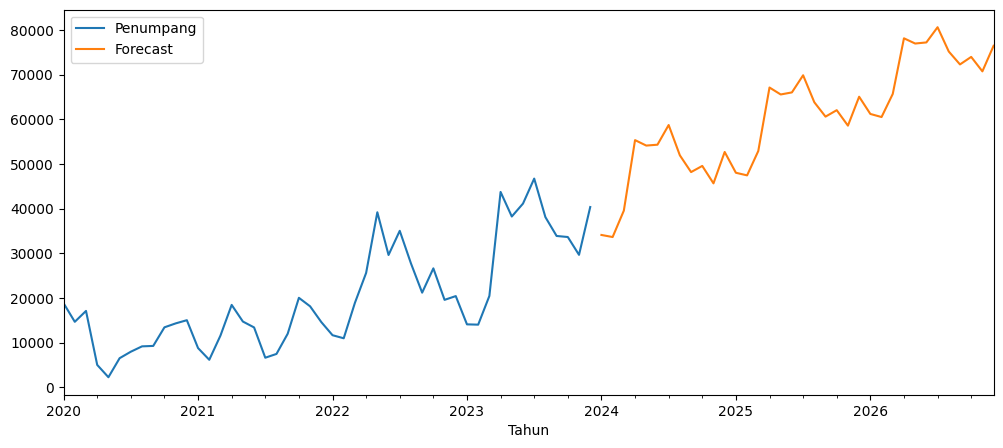

In [24]:
# Train the model on the full dataset 
model = model = SARIMAX(sea_passanger['Penumpang'], 
						order = (0, 1, 1), 
						seasonal_order =(2, 1, 1, 12)) 
result = model.fit() 

# Forecast for the next 3 years 
forecast = result.predict(start = len(sea_passanger), 
						end = (len(sea_passanger)-1) + 3 * 12, 
						typ = 'levels').rename('Forecast') 

# Plot the forecast values 
sea_passanger['Penumpang'].plot(figsize = (12, 5), legend = True) 
forecast.plot(legend = True) 
